# File for generating figures in the manuscript

This Notebook refers to the manuscript `outer-totalistic-network-automata.tex`

In [18]:
from matplotlib import pyplot as plt
import numpy as np
import cellpylib as cpl
import igraph as ig

from matplotlib import rcParams

from tqdm import tqdm

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

from src.analysis import hamming_weight, boolean_sens, return_equivalent_rule

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction
This part has no figures

### Local update diagram for the Game of Life

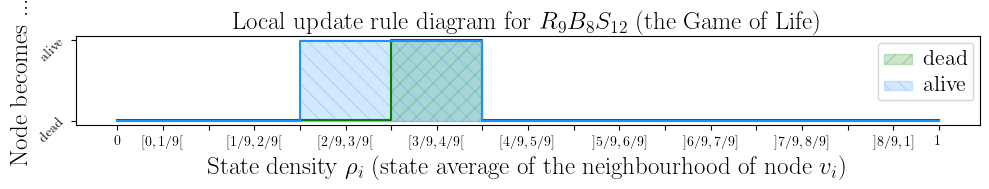

In [3]:
SAVEFIG = False
savename = 'gol_as_llna-diagram.jpg'

# local update rule diagram
def binary_indices(n: int) -> list:
    """
    Returns a list of indices where bits are 1 in the binary representation of n.
    """
    return [i for i, bit in enumerate(bin(n)[:1:-1]) if bit == '1']

resolution = 9

# GoL as LLNA model
beta = 8
sigma = 12
born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# plot both diagrams
fig, ax = plt.subplots(1,1,figsize=(10,2))
model.diagram(ax=ax)

# delete separate ax labels
size=18
ax.set_xlabel(fr'State density $\rho_i$ (state average of the neighbourhood of node $v_i$)', fontsize=size)
ax.set_ylabel(fr'Node becomes ...', fontsize=size)
ax.set_title(fr"Local update rule diagram for {model.__str__(latex=True)} (the Game of Life)", fontsize=size)

# Change font size AFTER the legend is created
for text in ax.legend().get_texts():
    text.set_fontsize(size-2)  # Change legend font size

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

### example of isomorphic rules

This is optional (I will probably delete this from the manuscript).

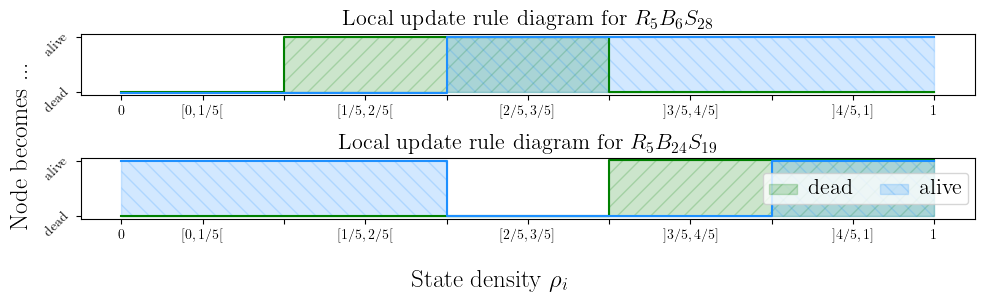

In [14]:
SAVEFIG = False
savename = 'compare-two-iso-rules.jpg'

# local update rule diagram
def binary_indices(n: int) -> list:
    """
    Returns a list of indices where bits are 1 in the binary representation of n.
    """
    return [i for i, bit in enumerate(bin(n)[:1:-1]) if bit == '1']

resolution = 5

# first model
beta = 6
sigma = 28
born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# second model
beta_iso = 2**resolution - 1 - np.sum([2**(resolution-1-i) for i in survive_if])
sigma_iso = 2**resolution - 1 - np.sum([2**(resolution-1-i) for i in born_if])
born_if_iso = binary_indices(beta_iso)
survive_if_iso = binary_indices(sigma_iso)
model_iso = LLNA(resolution, x=born_if_iso, y=survive_if_iso, iso=True)

# plot both diagrams
fig, axs = plt.subplots(2,1,figsize=(10,3))
model.diagram(ax=axs[0])
model_iso.diagram(ax=axs[1])

# delete separate ax labels
axs[0].set_ylabel(None)
axs[1].set_ylabel(None)
axs[0].set_xlabel(None)
axs[1].set_xlabel(None)

# rewrite ax titles
size=16
axs[0].set_title(fr"Local update rule diagram for {model.__str__(latex=True)}", fontsize=size)
axs[1].set_title(fr"Local update rule diagram for {model_iso.__str__(latex=True)}", fontsize=size)

# Change some legend props after the legend is created
axs[0].legend().remove()
legend = axs[1].legend(ncol=2, loc='center right')
for text in legend.get_texts():
    text.set_fontsize(size)  # Change legend font size

size=18
# fig.suptitle("Local update rule diagrams", fontsize=size)
fig.supxlabel(fr'State density $\rho_i$', fontsize=size)
fig.supylabel(fr'Node becomes ...', fontsize=size)

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

# Genotype parameters

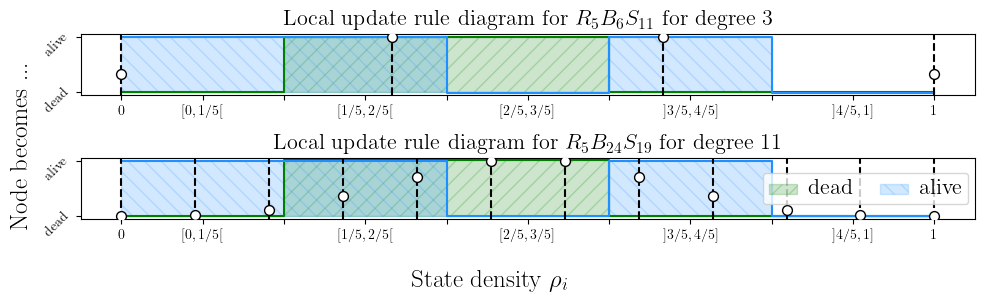

In [15]:
SAVEFIG = False
savename = 'compare-two-degrees_diagram.jpg'

resolution = 5
degree0 = 3
degree1 = 11

# model
beta = 6
sigma = 11
born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# plot both diagrams
fig, axs = plt.subplots(2,1,figsize=(10,3))
model.diagram(ax=axs[0], degree=degree0, plot_dist=True)
model.diagram(ax=axs[1], degree=degree1, plot_dist=True)

# delete separate ax labels
axs[0].set_ylabel(None)
axs[1].set_ylabel(None)
axs[0].set_xlabel(None)
axs[1].set_xlabel(None)

# rewrite ax titles
size=16
axs[0].set_title(fr"Local update rule diagram for {model.__str__(latex=True)} for degree {degree0}", fontsize=size)
axs[1].set_title(fr"Local update rule diagram for {model_iso.__str__(latex=True)} for degree {degree1}", fontsize=size)

# Change some legend props after the legend is created
axs[0].legend().remove()
legend = axs[1].legend(ncol=2, loc='center right')
for text in legend.get_texts():
    text.set_fontsize(size)  # Change legend font size

size=18
# fig.suptitle("Local update rule diagrams", fontsize=size)
fig.supxlabel(fr'State density $\rho_i$', fontsize=size)
fig.supylabel(fr'Node becomes ...', fontsize=size)

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

### Correlation Hamming weight and Boolean sensitivity

In [19]:
# let's compare the sensitivity with the Hamming weight for all NAs

resolution = 5
degree_rules = 3

sigmas=range(2**resolution)
betas=range(2**resolution)

HWs_rules = []
BSs_rules = []
equiv_rule_list = []
for beta in tqdm(betas, total=len(betas)):
    born_if = binary_indices(beta)
    for sigma in sigmas:
        if (beta, sigma) not in equiv_rule_list:
            survive_if = binary_indices(sigma)
            HW = hamming_weight(resolution, born_if, survive_if, degree_rules, norm=True, iso=True)
            BS = boolean_sens(resolution, born_if, survive_if, degree_rules, norm_degree=True, iso=True)
            HWs_rules.append(HW)
            BSs_rules.append(BS)
            # add the equivalent rule to the list
            beta_equiv, sigma_equiv = return_equivalent_rule(resolution, born_if, survive_if, return_decimals=True)
            equiv_rule_list.append((beta_equiv, sigma_equiv))

100%|██████████| 32/32 [00:01<00:00, 21.14it/s]


In [26]:
# let's compare the sensitivity with the Hamming weight for all non-equivalent NAs

resolution = 5

beta=6
sigma=11
max_degree = 100

born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model_degrees = LLNA(resolution, x=born_if, y=survive_if, iso=True)

HWs_degrees = []
BSs_degrees = []
for degree in range(1,max_degree+1):
    HW = hamming_weight(resolution, born_if, survive_if, degree, norm=True, iso=True)
    BS = boolean_sens(resolution, born_if, survive_if, degree, norm_degree=True, iso=True)
    HWs_degrees.append(HW)
    BSs_degrees.append(BS)

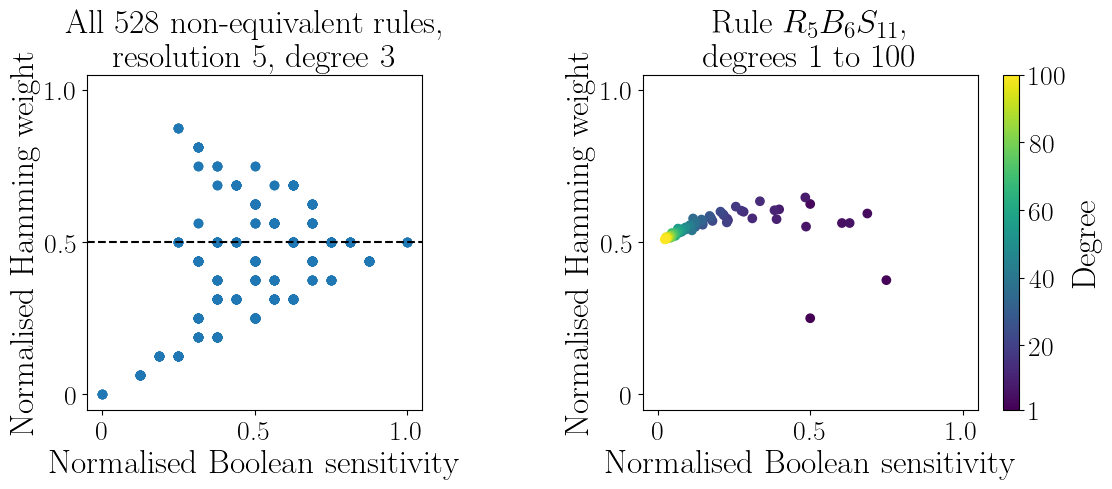

In [ ]:
SAVEFIG = False
savename='correlation-HW-BS.pdf'

fig, axs = plt.subplots(1,2,figsize=(12,5))
fontsize=24

axs[0].scatter(BSs_rules, HWs_rules)
axs[0].set_title(f"All 528 non-equivalent rules,\nresolution {resolution}, degree {degree_rules}", fontsize=fontsize)
axs[0].axhline(.5, color='black', linestyle='--')

sc = axs[1].scatter(BSs_degrees, HWs_degrees, c=range(1, max_degree+1), cmap='viridis')
axs[1].set_title(f"Rule {model_degrees.__str__(latex=True)},\ndegrees $1$ to ${max_degree}$", fontsize=fontsize)

# Add colorbar linked to the scatter plot
cbar = fig.colorbar(sc, ax=axs[1], ticks=[1, 20, 40, 60, 80, 100])
cbar.set_label("Degree", fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize-4)

for ax in axs:
    ax.set_xlabel("Normalised Boolean sensitivity", fontsize=fontsize)
    ax.set_ylabel("Normalised Hamming weight", fontsize=fontsize)
    ax.set_xlim([-0.05,1.05])
    xticks = [0, 0.5, 1.] # [0, .2, .4, .6, .8, 1]
    yticks = xticks
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=fontsize-4)
    ax.set_ylim([-0.05, 1.05])
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=fontsize-4)
    ax.set_aspect(1.0)

fig.tight_layout()


if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')


### Boolean sensitivity and Hamming weight histograms for various networks types

# Phenotype parameters